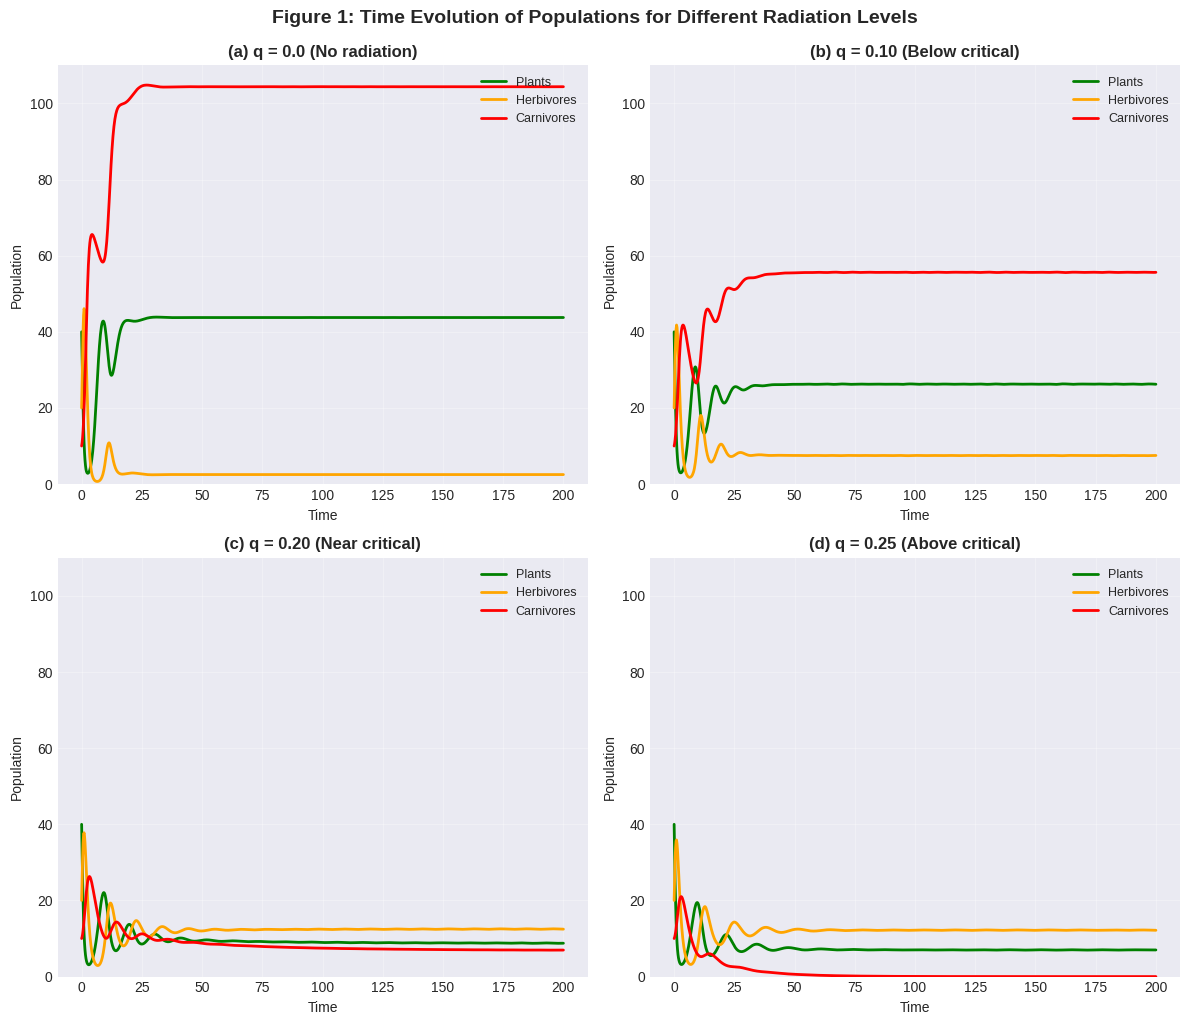

Simulating for different q values...


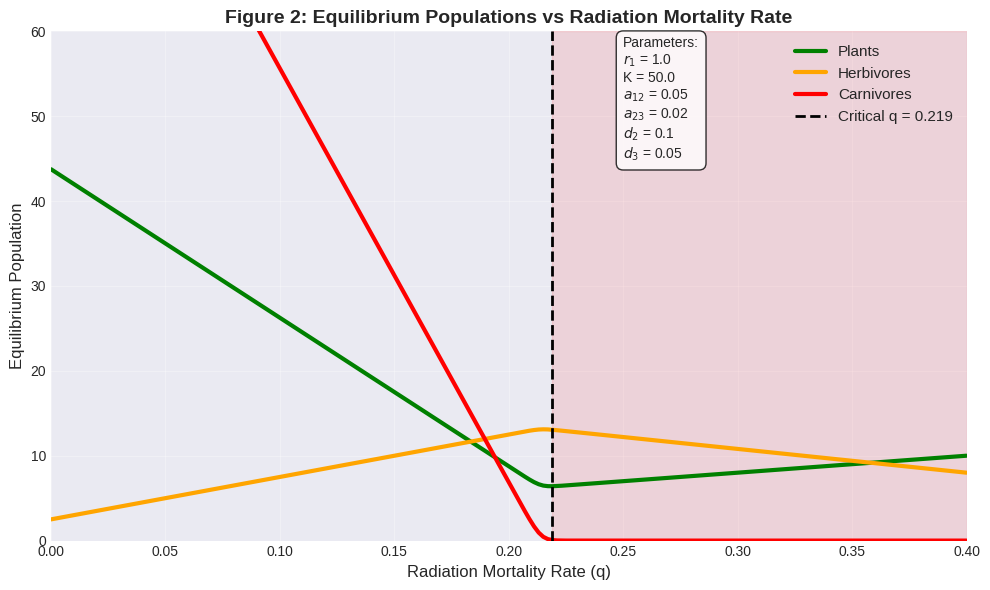


RESULTS SUMMARY
Analytical critical q: 0.214
Numerical critical q: 0.219
Difference: 0.0051

Equilibrium populations:
At q = 0.0:
  Plants: 43.8
  Herbivores: 2.5
  Carnivores: 104.4

At q = 0.219 (critical):
  Plants: 6.4
  Herbivores: 13.1
  Carnivores: 0.1

At q = 0.3 (collapse):
  Plants: 8.0
  Herbivores: 10.8
  Carnivores: 0.0


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Set up clean plotting style
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# ============================================================================
# Model parameters (matching analytical derivation)
# ============================================================================
r1 = 1.0       # intrinsic growth rate for plants
K = 50.0       # carrying capacity for plants
a12 = 0.05     # predation rate: herbivores on plants
a23 = 0.02     # predation rate: carnivores on herbivores
d2 = 0.1       # natural death rate of herbivores
d3 = 0.05      # natural death rate of carnivores

# Initial populations
N0 = [40.0, 20.0, 10.0]

# Time span
t_span = (0, 200)
t_eval = np.linspace(0, 200, 1000)

# ============================================================================
# Define the ODE system
# ============================================================================
def three_species(t, N, q):
    """ODE system for three-species ecosystem with radiation"""
    N1, N2, N3 = N
    dN1dt = r1 * N1 * (1 - N1 / K) - a12 * N1 * N2 - q * N1
    dN2dt = a12 * N1 * N2 - a23 * N2 * N3 - (d2 + q) * N2
    dN3dt = a23 * N2 * N3 - (d3 + q) * N3
    return [dN1dt, dN2dt, dN3dt]

# ============================================================================
# FIGURE 1: Time evolution for different q values (clean version)
# ============================================================================
fig1, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Select 4 representative q values
q_values = [0.0, 0.1, 0.2, 0.25]
titles = ['(a) q = 0.0 (No radiation)',
          '(b) q = 0.10 (Below critical)',
          '(c) q = 0.20 (Near critical)',
          '(d) q = 0.25 (Above critical)']

colors = {'Plants': 'green', 'Herbivores': 'orange', 'Carnivores': 'red'}

for idx, (q, title) in enumerate(zip(q_values, titles)):
    # Solve ODE
    sol = solve_ivp(three_species, t_span, N0, args=(q,),
                    t_eval=t_eval, method='RK45')

    ax = axes[idx]

    # Plot all three species
    ax.plot(sol.t, sol.y[0], color=colors['Plants'], linewidth=2, label='Plants')
    ax.plot(sol.t, sol.y[1], color=colors['Herbivores'], linewidth=2, label='Herbivores')
    ax.plot(sol.t, sol.y[2], color=colors['Carnivores'], linewidth=2, label='Carnivores')

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Time', fontsize=10)
    ax.set_ylabel('Population', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.set_ylim(0, 110)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Figure 1: Time Evolution of Populations for Different Radiation Levels',
             fontsize=14, fontweight='bold', y=1.02)
plt.savefig('figure1_time_evolution.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# FIGURE 2: Equilibrium populations vs q (clean version)
# ============================================================================
print("Simulating for different q values...")
q_range = np.linspace(0, 0.4, 200)
equilibrium = np.zeros((3, len(q_range)))

for i, q in enumerate(q_range):
    # Longer simulation to reach equilibrium
    sol = solve_ivp(three_species, (0, 500), N0, args=(q,),
                    t_eval=np.linspace(400, 500, 100), method='RK45')

    # Take average of last 50 time points
    equilibrium[:, i] = np.mean(sol.y[:, -50:], axis=1)

# Find critical q (where carnivores approach zero)
critical_idx = np.where(equilibrium[2, :] < 0.1)[0]
if len(critical_idx) > 0:
    q_critical = q_range[critical_idx[0]]
else:
    q_critical = 0.214  # Fallback to analytical value

fig2, ax = plt.subplots(figsize=(10, 6))

# Plot equilibrium populations
ax.plot(q_range, equilibrium[0, :], color='green', linewidth=3, label='Plants')
ax.plot(q_range, equilibrium[1, :], color='orange', linewidth=3, label='Herbivores')
ax.plot(q_range, equilibrium[2, :], color='red', linewidth=3, label='Carnivores')

# Mark critical q
ax.axvline(x=q_critical, color='black', linestyle='--', linewidth=2,
           label=f'Critical q = {q_critical:.3f}')

# Shade the collapse region
ax.axvspan(q_critical, 0.4, alpha=0.1, color='red')

ax.set_xlabel('Radiation Mortality Rate (q)', fontsize=12)
ax.set_ylabel('Equilibrium Population', fontsize=12)
ax.set_title('Figure 2: Equilibrium Populations vs Radiation Mortality Rate',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 0.4)
ax.set_ylim(0, 60)

# Add text box with parameters
params_text = f'Parameters:\n$r_1$ = {r1}\nK = {K}\n$a_{{12}}$ = {a12}\n$a_{{23}}$ = {a23}\n$d_2$ = {d2}\n$d_3$ = {d3}'
ax.text(0.25, 45, params_text, fontsize=10,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('figure2_equilibrium_vs_q.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# Print results
# ============================================================================
print("\n" + "="*50)
print("RESULTS SUMMARY")
print("="*50)
print(f"Analytical critical q: 0.214")
print(f"Numerical critical q: {q_critical:.3f}")
print(f"Difference: {abs(0.214 - q_critical):.4f}")

print("\nEquilibrium populations:")
print(f"At q = 0.0:")
print(f"  Plants: {equilibrium[0,0]:.1f}")
print(f"  Herbivores: {equilibrium[1,0]:.1f}")
print(f"  Carnivores: {equilibrium[2,0]:.1f}")

print(f"\nAt q = {q_critical:.3f} (critical):")
q_idx = np.argmin(np.abs(q_range - q_critical))
print(f"  Plants: {equilibrium[0,q_idx]:.1f}")
print(f"  Herbivores: {equilibrium[1,q_idx]:.1f}")
print(f"  Carnivores: {equilibrium[2,q_idx]:.1f}")

print(f"\nAt q = 0.3 (collapse):")
q_idx = np.argmin(np.abs(q_range - 0.3))
print(f"  Plants: {equilibrium[0,q_idx]:.1f}")
print(f"  Herbivores: {equilibrium[1,q_idx]:.1f}")
print(f"  Carnivores: {equilibrium[2,q_idx]:.1f}")